# MatrixDesing

В этом ноутбуке я построю матрицу взаимодействия и протестирую AILS модель.

## Импорт библиоткек

In [89]:
import pandas as pd
import numpy as np
import implicit
import os
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  
import matplotlib.pyplot as plt
from pathlib import Path

## Загрузка данных

In [90]:
BASE_PATH = os.path.abspath("../../../Tables/CleanTable")

In [91]:
users_clean = pd.read_csv(os.path.join(BASE_PATH, 'users_clean.csv'), encoding='utf-8')
items_dim = pd.read_csv(os.path.join(BASE_PATH, 'items_dim.csv'), encoding='utf-8')
user_items = pd.read_csv(os.path.join(BASE_PATH, 'user_item_clean.csv'), encoding='utf-8')

## Построение матрицы __User-Item__

Формула для Confidence (weight)

__Weight = 1 + log(N)__, где N - количество посещений

Такая формула была выбрана, потому что она:
1)  Учитывает размерность самых частых услуг (log сгладит услуги с крупными посещениями).
2) Учитывает частоту посещений и поощеряет услугу, если клиент часто на неё ходит.

Тогда матрица будет в формате:

`id_user` | `id_item` | `Weight`

#### Считаем Weight

In [92]:
# 1. Считаем посещения с весами
user_item_matrix = user_items.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')
print(user_item_matrix, end='\n'*5)
# 2. Weight = 1 + log(N)
user_item_matrix['confidence'] = 1 + np.log(user_item_matrix['N_visits'])
print(user_item_matrix)

      id_user  id_item  N_visits
0           4      160         1
1           7      104         2
2           7      130         1
3           9      130         2
4          12       74         1
...       ...      ...       ...
2247     2879      104         1
2248     2881      200         2
2249     2882      104         4
2250     2883      104         1
2251     2885      104         1

[2252 rows x 3 columns]




      id_user  id_item  N_visits  confidence
0           4      160         1    1.000000
1           7      104         2    1.693147
2           7      130         1    1.000000
3           9      130         2    1.693147
4          12       74         1    1.000000
...       ...      ...       ...         ...
2247     2879      104         1    1.000000
2248     2881      200         2    1.693147
2249     2882      104         4    2.386294
2250     2883      104         1    1.000000
2251     2885      104         1    1.000000

[2252 rows x 4 columns]


#### CSR матрица

Требуедтся переопределить id, из-за того что в них есть пропуски и матрица из-за слишком разряженная

In [93]:
class IDMapper:
    def __init__(self, ids):
        self.unique_ids = sorted(set(ids))
        self.id_to_idx = {id_: i for i, id_ in enumerate(self.unique_ids)}
        self.idx_to_id = {i: id_ for i, id_ in enumerate(self.unique_ids)}

    def to_idx(self, ids):
        return ids.map(self.id_to_idx)

    @property
    def size(self):
        return len(self.unique_ids)

In [94]:
user_mapper = IDMapper(user_items['id_user'])
item_mapper = IDMapper(user_items['id_item'])

In [95]:
rows = user_mapper.to_idx(user_item_matrix['id_user'])
cols = item_mapper.to_idx(user_item_matrix['id_item'])
data = user_item_matrix['confidence']


In [96]:
user_item_sparse = sparse.csr_matrix((data, (rows, cols)), 
                                   shape=(user_mapper.size, item_mapper.size))

In [97]:
user_item_sparse.shape

(1264, 161)

#### Оценка матрицы

In [99]:
import numpy as np
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===")
weights = user_item_sparse.data
for i in range(1, 11):
    count = np.sum(weights >= 1 + np.log(i))
    pct = count / len(weights) * 100
    print(f"N={i} → вес≥{1+np.log(i):.2f}: {count} ({pct:.1f}%)")



=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===
N=1 → вес≥1.00: 2252 (100.0%)
N=2 → вес≥1.69: 629 (27.9%)
N=3 → вес≥2.10: 244 (10.8%)
N=4 → вес≥2.39: 113 (5.0%)
N=5 → вес≥2.61: 67 (3.0%)
N=6 → вес≥2.79: 53 (2.4%)
N=7 → вес≥2.95: 45 (2.0%)
N=8 → вес≥3.08: 37 (1.6%)
N=9 → вес≥3.20: 34 (1.5%)
N=10 → вес≥3.30: 30 (1.3%)


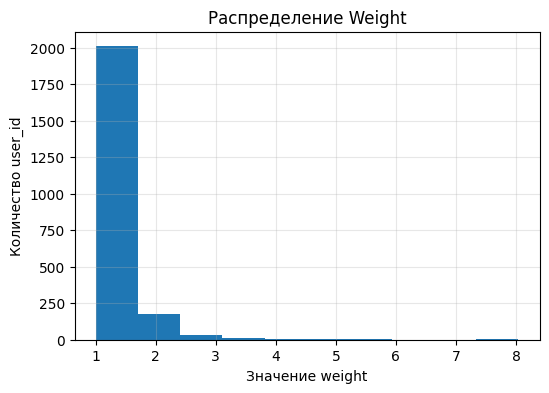

In [100]:
plt.figure(figsize=(6,4))

plt.title('Распределение Weight')
plt.xlabel('Значение weight')
plt.ylabel('Количество user_id')

plt.hist(data)
plt.grid(True, alpha=0.3)
plt.show()

In [101]:
print("=== БАЗОВАЯ ИНФОРМАЦИЯ ===")
print(f"Форма матрицы: {user_item_sparse.shape}")
print(f"NNZ (непустых): {user_item_sparse.nnz}")
print(f"Доля заполненности: {user_item_sparse.nnz / (user_item_sparse.shape[0] * user_item_sparse.shape[1]):.4f}")
print(f"Диапазон весов: {user_item_sparse.data.min():.2f} → {user_item_sparse.data.max():.2f}")
print(f"Средний вес: {user_item_sparse.data.mean():.2f}")

=== БАЗОВАЯ ИНФОРМАЦИЯ ===
Форма матрицы: (1264, 161)
NNZ (непустых): 2252
Доля заполненности: 0.0111
Диапазон весов: 1.00 → 8.04
Средний вес: 1.29


In [103]:
print("\n=== ТОП ===")
user_sums = np.array(user_item_sparse.sum(axis=1)).flatten()
item_sums = np.array(user_item_sparse.sum(axis=0)).flatten()

print(f"Самый активный user_id: {np.argmax(user_sums)} (вес: {user_sums.max():.1f})")
print(f"Самая популярная услуга item_id: {np.argmax(item_sums)} (вес: {item_sums.max():.1f})")



=== ТОП ===
Самый активный user_id: 1087 (вес: 296.4)
Самая популярная услуга item_id: 67 (вес: 806.2)


In [112]:
users_clean[users_clean['id_user']==1087][[col for col in users_clean.columns if col != 'Телефон']]

,id_user,Имя,Категории,Оплачено в руб,Последний визит
1022,1087,Валентина,обычный,7450.0,2025-08-20 14:00:00


In [113]:
items_dim[items_dim['id_item'] == 67]

,id_item,Название услуги или товара,Категория товара или услуги в продаже
67,67,коррекция нарощенных ногтей (большая),Маникюр / Педикюр


#### Сохранение матрицы

In [106]:
result_path = Path('../../../results/matrices')


In [107]:
sparse.save_npz(result_path / 'artnail_user_item_sparse_update.npz', user_item_sparse)
print(f"  Путь: {result_path / 'artnail_user_item_sparse.npz'}")
print(f"  Размер: {os.path.getsize(result_path / 'artnail_user_item_sparse.npz') / 1024:.1f} КБ")

  Путь: ..\..\..\results\matrices\artnail_user_item_sparse.npz
  Размер: 4.0 КБ


In [111]:
[id_item for id_item in user_item_sparse['id_item'] if id_item not in items_dim['id_item']]

IndexError: Index dimension must be 1 or 2